# UFC Finish Dynamics: An Observational Study (2015 to 2026)

## Overview

This notebook is an *observational* tour of how fights end in the modern UFC.
Rather than building a predictive model, it follows the data to surface **trends
and patterns** in finishes (knockouts and submissions) versus decisions, across
time and across divisions.

### Guiding questions
1. Is the UFC finish environment drifting over time, or is it mostly stable?
2. How has the *composition* of outcomes (KO, submission, decision) shifted year to year?
3. Which divisions are structurally finish-heavy, and which lean on the judges?
4. Do divisions differ not just in *how often* fights finish, but in *how* they finish?

### Data
- Scraped from [ufcstats.com](http://ufcstats.com/) event pages via `src/scraping.py`
- Fight-level records: event metadata, bout statistics, result labels, round/time, and bonus/title indicators
- Scope: the modern era from 2015 onward, restricted to current UFC divisions

### What the data says
- The aggregate finish rate hovers in a stable band near the 50% level, with year-to-year volatility but no durable trend break.
- Outcome composition is fairly persistent, with knockouts and unanimous decisions dominating the mix.
- Division context is the dominant axis of variation. We see heavier men's classes are finish-dominant, while several women's divisions are decision-heavy.
- Divisions differ in finish *mechanism* as well. Heavyweight is KO-driven, while Women's Strawweight often goes to the judges.

## 1) Setup

In [91]:
from pathlib import Path
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.analysis_utils import (
    DEFAULT_HEATMAP_ORDER,
    DEFAULT_OUTCOME_ORDER,
    compute_division_finish_rates,
    compute_outcome_mix_by_division,
    compute_yearly_finish_stats,
    get_project_root,
    load_fight_data,
    prepare_analysis_frame,
    save_processed_data,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#b0b0b0",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.35,
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

ACCENT = "#1b3b6f"      # deep navy for primary series
SEQ_CMAP = "mako"        # sequential colormap for heatmaps / stacked areas

project_root = get_project_root()
figs_dir = project_root / "figs"
figs_dir.mkdir(parents=True, exist_ok=True)

EXPECTED_FIGURES = [
    "finish_rate_trend.png",
    "outcome_composition_trend.png",
    "division_finish_heatmap.png",
    "division_outcome_mix.png",
]

def save_figure(fig, filename: str, dpi: int = 200) -> Path:
    path = figs_dir / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    return path

## 2) Load and prepare data

In [92]:
raw_df = load_fight_data()
# No upper date bound, so the analysis always extends to the most recent event.
df = prepare_analysis_frame(raw_df, start_date="2015-01-01")
processed_path = save_processed_data(df)

print(f"Rows in analysis frame: {len(df):,}")
print(f"Year span: {df['Year'].min()}-{df['Year'].max()}")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

df.head()

INFO | loading dataset from /Users/juanvilla/Documents/Personal-Projects/Project-Jan-2025/ufc-analytics/data/raw/ufc_event_data.csv
INFO | saved processed dataset to /Users/juanvilla/Documents/Personal-Projects/Project-Jan-2025/ufc-analytics/data/processed/ufc_event_data.csv


Rows in analysis frame: 5,524
Year span: 2015-2026
Date range: 2015-01-03 -> 2026-06-20


,Event,Date,Location,WL,Fighter_A,Fighter_B,Fighter_A_KD,Fighter_B_KD,Fighter_A_STR,Fighter_B_STR,...,Round,Time,Weight_Class,Title,Fight_Bonus,Perf_Bonus,Sub_Bonus,KO_Bonus,Year,Outcome
0,UFC Fight Night: Kape vs. Horiguchi,2026-06-20,"Las Vegas, Nevada, USA",WIN,Manel Kape,Kyoji Horiguchi,1,0,19,27,...,3,2:42,Flyweight,0,0,1,0,0,2026,KO
1,UFC Fight Night: Kape vs. Horiguchi,2026-06-20,"Las Vegas, Nevada, USA",WIN,Navajo Stirling,Ion Cutelaba,0,0,52,19,...,2,3:23,Light Heavyweight,0,0,0,0,0,2026,KO
2,UFC Fight Night: Kape vs. Horiguchi,2026-06-20,"Las Vegas, Nevada, USA",WIN,Christian Rodriguez,Hyder Amil,1,0,20,23,...,1,3:43,Featherweight,0,0,0,0,0,2026,SUB
3,UFC Fight Night: Kape vs. Horiguchi,2026-06-20,"Las Vegas, Nevada, USA",WIN,Murtazali Magomedov,Melsik Baghdasaryan,0,0,5,3,...,1,1:17,Featherweight,0,0,1,0,0,2026,SUB
4,UFC Fight Night: Kape vs. Horiguchi,2026-06-20,"Las Vegas, Nevada, USA",WIN,Vinicius Oliveira,Andre Fili,1,0,105,40,...,2,4:56,Featherweight,0,1,0,0,0,2026,KO


## 3) How has the overall finish rate changed over time?

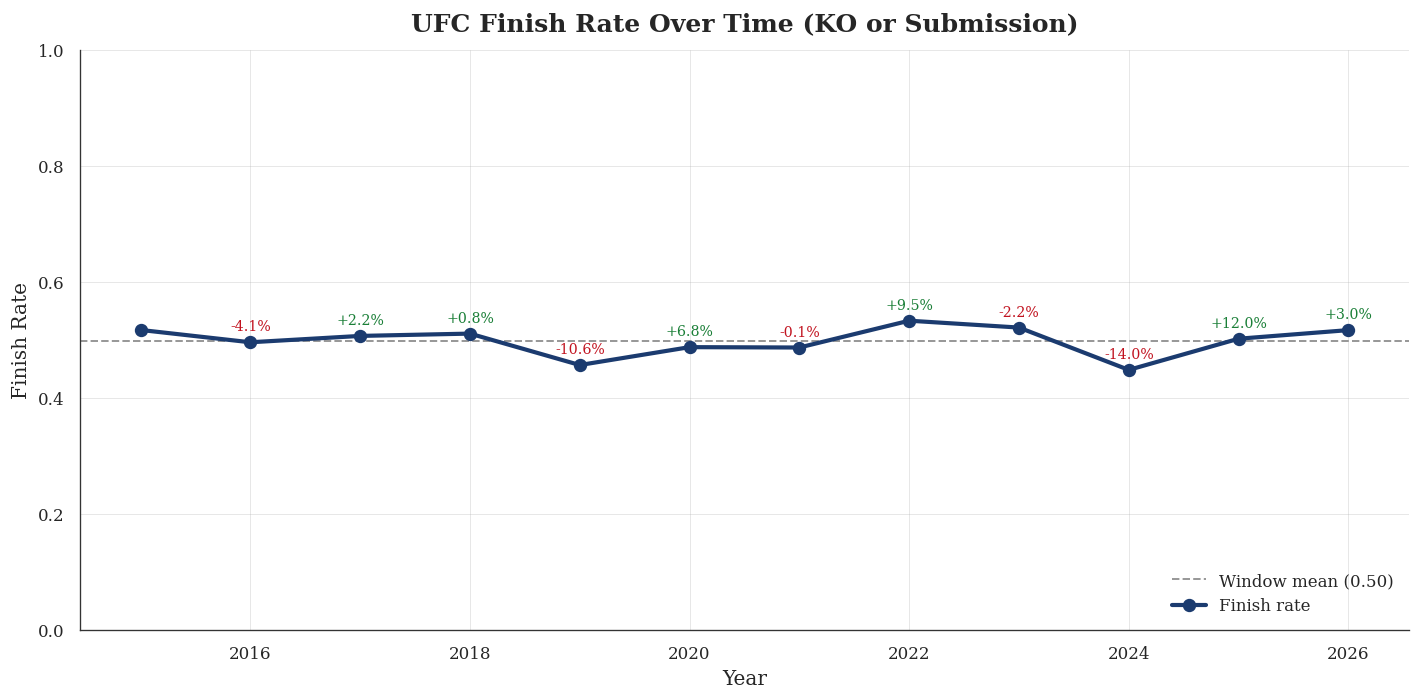

In [93]:
# Plot the yearly finish rate as a line, with the window mean as a dashed
# reference and a per-year percent-change label above each point.
yearly_stats = compute_yearly_finish_stats(df)
window_mean = yearly_stats["Finish_Rate"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.axhline(window_mean, color="#999999", linestyle="--", linewidth=1.2,
           label=f"Window mean ({window_mean:.2f})")
ax.plot(yearly_stats.index, yearly_stats["Finish_Rate"],
        marker="o", markersize=7, linewidth=2.5, color=ACCENT, label="Finish rate")

for year, finish_rate, pct_change in zip(
    yearly_stats.index[1:],
    yearly_stats["Finish_Rate"].iloc[1:],
    yearly_stats["Finish_Rate_Change_Pct"].iloc[1:],
):
    if pd.notna(pct_change):
        color = "#1a7f37" if pct_change > 0 else "#c1121f"
        ax.text(year, finish_rate + 0.02, f"{pct_change:+.1f}%",
                ha="center", fontsize=8.5, color=color)

ax.set_title("UFC Finish Rate Over Time (KO or Submission)")
ax.set_xlabel("Year")
ax.set_ylabel("Finish Rate")
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
save_figure(fig, "finish_rate_trend.png")
plt.show()

### What the trend shows

Across the full 2015 to 2026 window, yearly finish rates stay inside a tight band around **0.499**, with a standard deviation of just **0.026**. The sharpest year-over-year rise came in **2025** (+12.0%), and the steepest fall the year before in **2024** (-14.0%).

The pattern reads as noise rather than a stable trend. In **2026** the finish rate sits at **0.517**, close to the long-run average, so calendar year on its own tells us little about whether a given fight is likely to finish.

There is room here for a closer look. A potential follow-up would be to test whether the year-to-year movement is statistical noise or whether it tracks something concrete, such as roster turnover or shifts in matchmaking.

## 4) How has the composition of outcomes shifted over time?

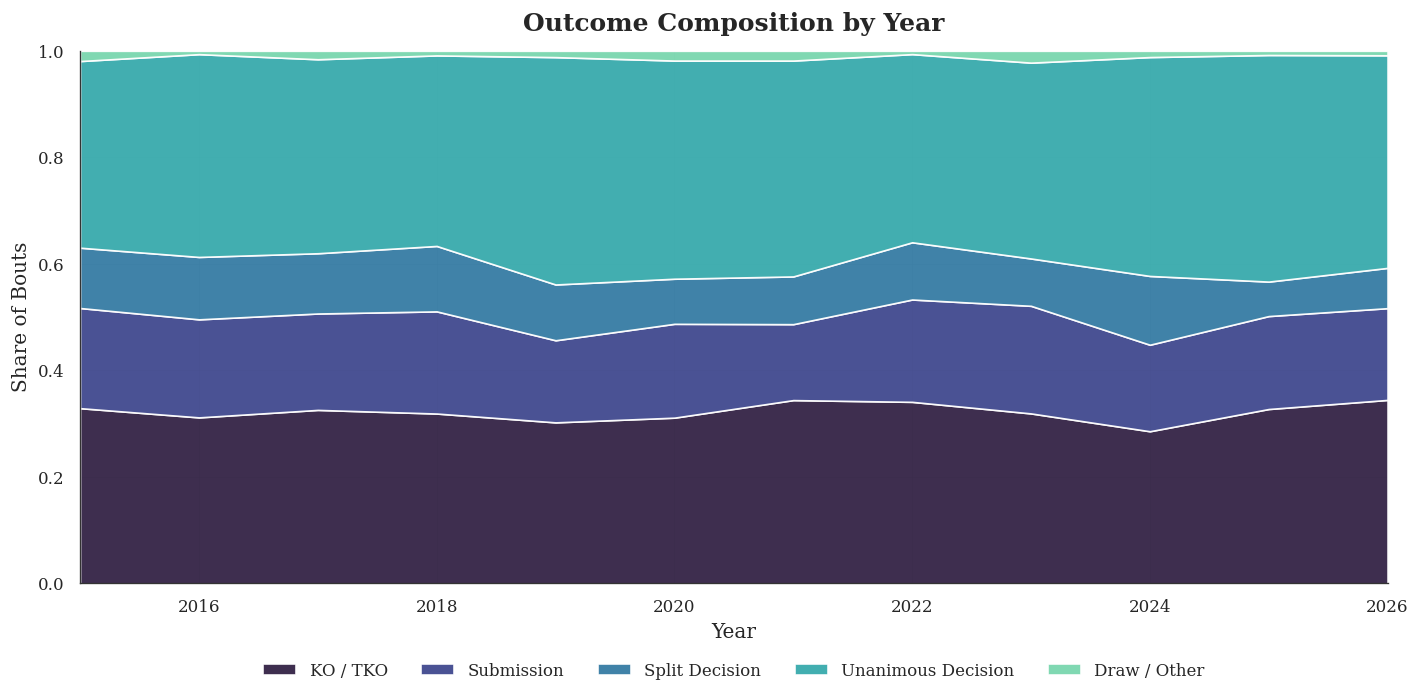

In [94]:
# Convert raw outcome counts into per-year shares, then draw them as a stacked
# area so the changing composition of outcomes is visible across the window.
outcome_order = ["KO", "SUB", "SDEC", "UDEC", "DRAW"]
outcome_labels = {
    "KO": "KO / TKO",
    "SUB": "Submission",
    "SDEC": "Split Decision",
    "UDEC": "Unanimous Decision",
    "DRAW": "Draw / Other",
}

composition = (
    df.groupby(["Year", "Outcome"]).size()
    .unstack(fill_value=0)
    .reindex(columns=outcome_order, fill_value=0)
)
composition_share = composition.div(composition.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette(SEQ_CMAP, len(outcome_order))
ax.stackplot(
    composition_share.index,
    *[composition_share[c] for c in outcome_order],
    labels=[outcome_labels[c] for c in outcome_order],
    colors=colors,
    alpha=0.95,
)
ax.set_title("Outcome Composition by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Bouts")
ax.set_ylim(0, 1)
ax.set_xlim(composition_share.index.min(), composition_share.index.max())
ax.margins(x=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
fig.tight_layout()
save_figure(fig, "outcome_composition_trend.png")
plt.show()

### Reading the composition

The mix of outcomes is remarkably persistent. Comparing the first year in the window with the last, the knockout share moved only from **0.329** in 2015 to **0.345** in 2026, submissions from **0.188** to **0.172**, and all decisions combined from **0.464** to **0.475**. Unanimous decisions and knockouts anchor the picture in every year; the bands shift modestly but never reorder.

This stability reinforces the previous figure. The finish narrative appears to be structural rather than a whole, moving target over time.

We can extend this analysis by looking across divisions to check whether the steady aggregate hides offsetting shifts underneath.

## 5) Which divisions finish most often?

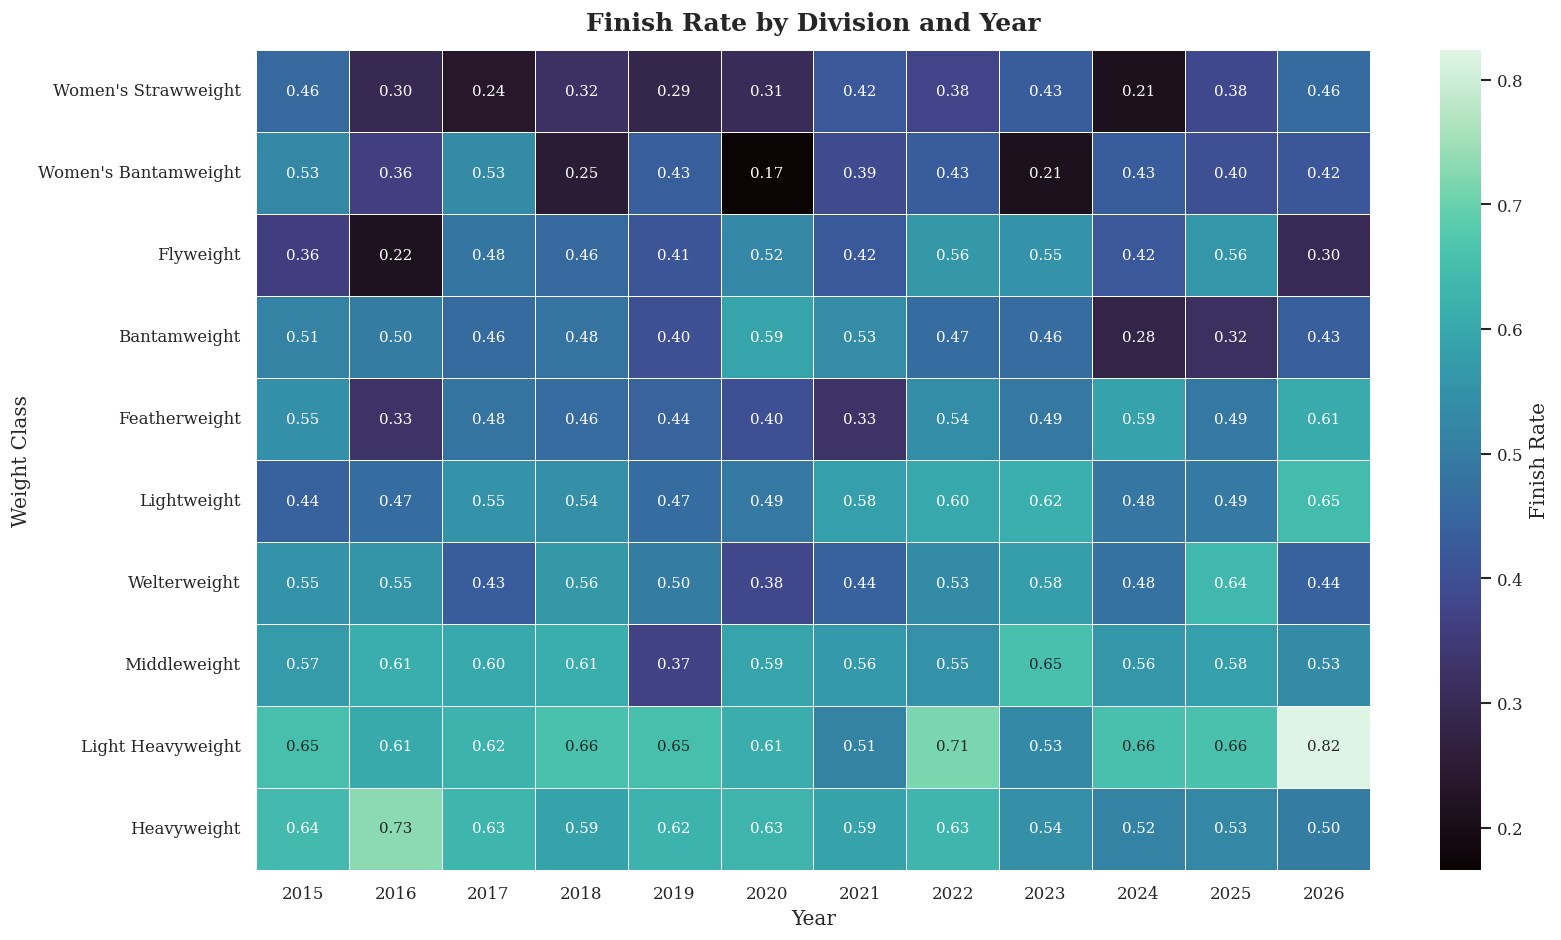

In [95]:
# Heatmap of finish rate with divisions on the rows and years on the columns,
# so structural differences between weight classes stand out at a glance.
heatmap_data = compute_division_finish_rates(df, weight_order=DEFAULT_HEATMAP_ORDER)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap=SEQ_CMAP,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor="white",
    annot_kws={"fontsize": 9},
    cbar_kws={"label": "Finish Rate"},
    ax=ax,
)
ax.set_title("Finish Rate by Division and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Weight Class")
plt.setp(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
save_figure(fig, "division_finish_heatmap.png")
plt.show()

### Reading the divisional split

Division effects are large. The average finish-rate spread from the most to the least finish-prone class is **29.3 percentage points**. The three most finish-heavy groups are **Light Heavyweight (0.642)**, **Heavyweight (0.596)** and **Middleweight (0.566)**; the most decision-leaning are **Flyweight (0.439)**, **Women's Bantamweight (0.379)** and **Women's Strawweight (0.349)**.

The environment in Light Heavyweight is structurally different from Women's Strawweight before any fighter-level detail enters the picture.

How much of this gap comes from size and power versus the stylistic norms of each division is an open question, and one that requires fighter-level striking and grappling data to untangle.

## 6) How do finish types differ across divisions?

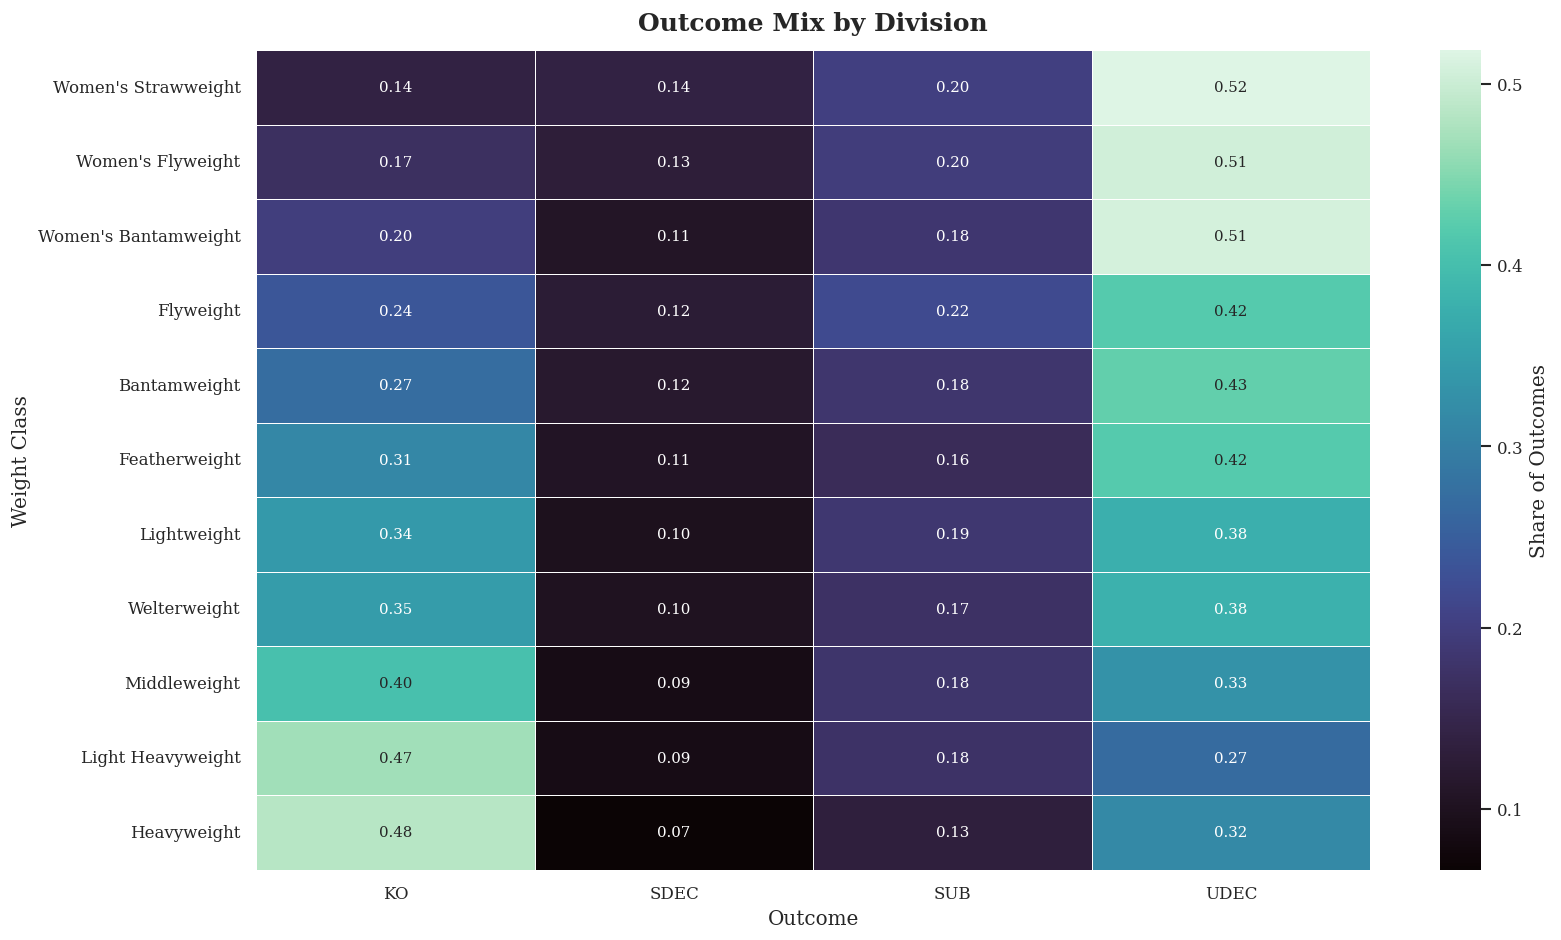

In [96]:
# Heatmap of each division's outcome mix (KO, submission and decision shares),
# which separates *how* divisions finish from *how often* they finish.
outcome_mix = compute_outcome_mix_by_division(df, weight_order=DEFAULT_OUTCOME_ORDER)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    outcome_mix,
    annot=True,
    fmt=".2f",
    cmap=SEQ_CMAP,
    linewidths=0.4,
    linecolor="white",
    annot_kws={"fontsize": 9},
    cbar_kws={"label": "Share of Outcomes"},
    ax=ax,
)
ax.set_title("Outcome Mix by Division")
ax.set_xlabel("Outcome")
ax.set_ylabel("Weight Class")
plt.setp(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
save_figure(fig, "division_outcome_mix.png")
plt.show()

### Reading the finish mechanisms

The contrast across classes is not only about how often fights end but how. Heavyweight is knockout-forward, with a KO share of **0.484** and comparatively few unanimous decisions (**0.316**). Women's Strawweight shows close to the opposite image, with a KO share of **0.140** and a unanimous-decision share of **0.519**.

Finish-rate differences are therefore not simply a matter of more versus less finishing. Divisions finish by different mechanisms.

A useful next step would be to pair this with submission rates and round-by-round timing, so the mechanism story extends beyond the knockout-versus-decision axis.

## 7) Figure export audit

In [97]:
# Sanity check before committing: confirm every expected figure was written to
# figs/, record its size, and fail loudly if any are missing.
figure_manifest = pd.DataFrame({"figure": EXPECTED_FIGURES})
figure_manifest["exists"] = figure_manifest["figure"].map(lambda name: (figs_dir / name).exists())
figure_manifest["size_kb"] = figure_manifest["figure"].map(
    lambda name: round((figs_dir / name).stat().st_size / 1024, 1) if (figs_dir / name).exists() else np.nan
)
figure_manifest["path"] = figure_manifest["figure"].map(lambda name: str((figs_dir / name).relative_to(project_root)))
display(figure_manifest)

missing = figure_manifest.loc[~figure_manifest["exists"], "figure"].tolist()
if missing:
    raise FileNotFoundError(f"Missing exported figures: {missing}")


,figure,exists,size_kb,path
0,finish_rate_trend.png,True,106.6,figs/finish_rate_trend.png
1,outcome_composition_trend.png,True,121.0,figs/outcome_composition_trend.png
2,division_finish_heatmap.png,True,266.8,figs/division_finish_heatmap.png
3,division_outcome_mix.png,True,185.6,figs/division_outcome_mix.png


## 8) Closing read

The clearest find in this data is the structural pattern across divisions, rather than temporal changes across the organization. Year to year, the finish environment is almost entirely stable. Both the overall finish rate and the composition of outcomes stay within a tight range, so time tells us little on its own.

What actually is more informative on a bout's outcome *where it sits on the divisional map*. Weight class shapes both **how often** fights finish and the **mechanism** by which they end: Heavyweight leans towards knockouts, while the lighter women's divisions are more often carried to the scorecards.

These are observations rather than conclusions, leaving further room for causal inference. Natural next steps to deepen the narrative:
- Track finish dynamics for individual divisions over time, not just in aggregate.
- Examine round-by-round timing to see *when* finishes happen within a fight.
- Compare title and main-event bouts against the undercard baseline.